In [75]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt

from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pickle import dump, load

##### Cargar datos

In [42]:
df_url_spam = pd.read_csv("../data/raw/12_url_spam.csv")
df_url_spam.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


Comprobar tamaño y duplicados

In [43]:
df_url_spam.shape

(2999, 2)

In [44]:

df_url_spam = df_url_spam.drop_duplicates().reset_index(drop=True)
df_url_spam.shape


(2369, 2)

Comprobar nulos y balance del dataset

In [45]:
df_url_spam.isna().sum()
df_url_spam["is_spam"].value_counts()


is_spam
False    2125
True      244
Name: count, dtype: int64

El dataset está fuertemente desbalanceado (2125 vs 244), por lo que métricas como accuracy deben interpretarse con cautela y es necesario prestar especial atención a recall y precision de la clase minoritaria.

##### Procesamiento del texto

Para poder entrenar el modelo es necesario aplicar antes un proceso de transformación al texto. Comenzamos convirtiendo símbolos típicos de URL en espacios dejando solo las letras, numeros y espacios, para normalizar y tokenizar

In [46]:
def preprocess_url(text: str):
    text = str(text).lower()

    # convertir símbolos típicos de URLs en espacios
    text = re.sub(r"[\/\.\-\_\?\=\&\:\%\+\~\#\,\@\(\)\[\]]", " ", text)

    # dejar solo letras, números y espacios
    text = re.sub(r"[^a-z0-9 ]", " ", text)

    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()

    # tokenizar
    return text.split()

df_url_spam["url_tokens"] = df_url_spam["url"].apply(preprocess_url)
df_url_spam[["url", "url_tokens"]].head()

,url,url_tokens
0,https://briefingday.us8.list-manage.com/unsubs...,"[https, briefingday, us8, list, manage, com, u..."
1,https://www.hvper.com/,"[https, www, hvper, com]"
2,https://briefingday.com/m/v4n3i4f3,"[https, briefingday, com, m, v4n3i4f3]"
3,https://briefingday.com/n/20200618/m#commentform,"[https, briefingday, com, n, 20200618, m, comm..."
4,https://briefingday.com/fan,"[https, briefingday, com, fan]"


##### Lematización y stopwords 

El siguiente paso es la lematización del texto, que es el proceso de simplificación de las palabras a su forma base o canónica, de manera que palabras con diferentes formas, pero el mismo núcleo semántico, se traten como una sola palabra. Por ejemplo, los verbos "corriendo", "corrió" y "corre" serán lematizados a "correr", así como las palabras "mejores" y "mejor" podrían ser lematizadas a "bueno".

Además, aprovechando la lematización, eliminaremos también las stopwords, que son palabras que consideramos irrelevantes para el análisis de texto porque aparece con mucha frecuencia en el lenguaje y no aporta información significativa. Existen dos formas: crear nosotros nuestra propia lista de palabras a eliminar o utilizar librerías externas.

Ambas tareas las llevaremos a cabo con la librería de Python NLTK, que es una de las más importantes en términos del NLP:


In [47]:
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_url(tokens):
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if len(t) > 2]  # en URLs conviene no ser demasiado agresivo
    return tokens

df_url_spam["url_tokens"] = df_url_spam["url_tokens"].apply(lemmatize_url)
df_url_spam["url_tokens"].head()


[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    [http, briefingday, us8, list, manage, com, un...
1                              [http, www, hvper, com]
2                   [http, briefingday, com, v4n3i4f3]
3      [http, briefingday, com, 20200618, commentform]
4                        [http, briefingday, com, fan]
Name: url_tokens, dtype: object

Se suaviza el filtrado por longitud (`len(t)>2`) para preservar tokens cortos informativos propios de URLs, que podrían perderse con un procesamiento más agresivo.

##### WordCloud

Vamos a crear una representación visual que permita identificar rápidamente los términos o conceptos más relevantes o repetidos en un conjunto de datos, ya que las palabras más frecuentes o significativas sobresalen por su tamaño. Lo separaremos por clases para ver que palabras (tokens) caraterizan a cadda clase, de otra manera no lo veriamos si mezclamos el dataset completo.

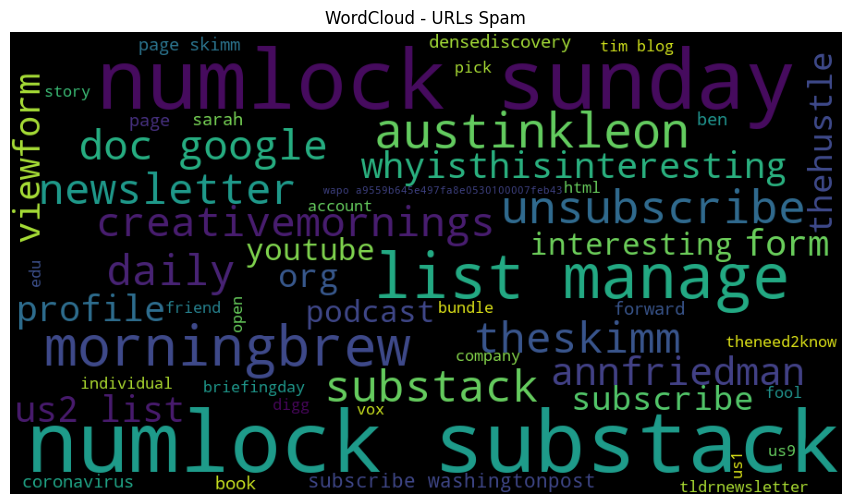

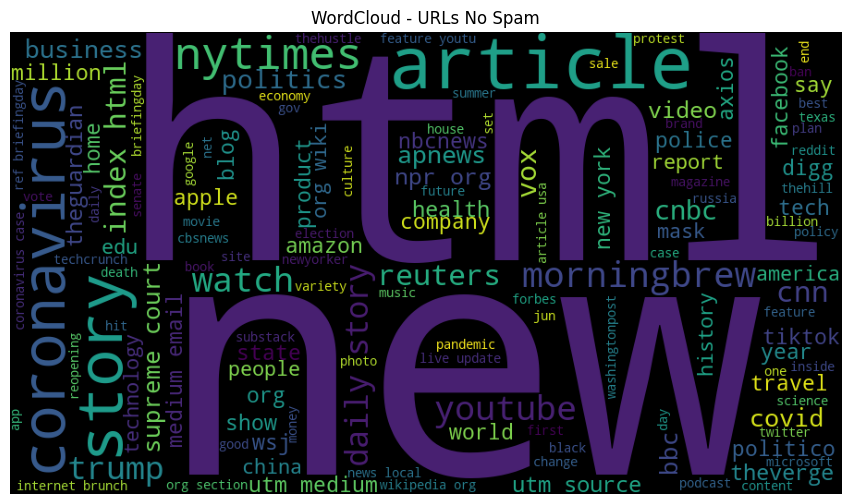

In [48]:
spam_text = " ".join([" ".join(toks) for toks in df_url_spam.loc[df_url_spam["is_spam"] == 1, "url_tokens"]])
ham_text  = " ".join([" ".join(toks) for toks in df_url_spam.loc[df_url_spam["is_spam"] == 0, "url_tokens"]])

wc_spam = WordCloud(width=900, height=500, background_color="black",
                    max_words=200, min_font_size=10, random_state=42).generate(spam_text)

wc_ham = WordCloud(width=900, height=500, background_color="black",
                   max_words=200, min_font_size=10, random_state=42).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_spam)
plt.axis("off")
plt.title("WordCloud - URLs Spam")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(wc_ham)
plt.axis("off")
plt.title("WordCloud - URLs No Spam")
plt.show()


##### Vectorización y split para el modelo

Antes de entrenar el modelo es convertirlo en números, ya que los modelos no pueden entrenar con categorías textuales. Primero realizaremos la separacion del texto para TF-IDF para evitar fuga de información. TF-IDF aprende estadísticas globales del corpus, por lo que ajustarlo con todo el dataset incluiría información del conjunto de test y sesgaría la evaluación del modelo. Al usar TfidfVectorizer, transformamos una colección de documentos de texto en una matriz numérica que representa la importancia relativa de cada palabra en cada documento, en relación con el corpus entero. 


In [49]:
# preparar texto
X_text = [" ".join(toks) for toks in df_url_spam["url_tokens"]]
y = df_url_spam["is_spam"].astype(int)

#Train/test split
X_train_txt, X_test_txt, y_train, y_test = train_test_split(X_text,
                                                            y,
                                                            test_size=0.2,
                                                            random_state=42,
                                                            stratify=y)# mantener la misma prporcion de clases, dataset desbalanceado

# vectorizacion TF_IDF
vectorizer = TfidfVectorizer(max_features=5000,
                             max_df =0.8,
                             min_df=5)

X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)

#Comprobar division
X_train.shape, X_test.shape


((1895, 504), (474, 504))

Tras el split 80/20, en `X_train` obtenemos 1895 muestras y en `X_test` 474. La vectorización TF-IDF genera 504 términos, es decir, el vocabulario final tras aplicar los filtros min_df=5 y max_df=0.8 (limitando ruido y términos demasiado raros o demasiado frecuentes).

##### Entrenamiento del modelo con SVM (maquina de vector soporte) y predicción

In [50]:
model = SVC(kernel = "linear", random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

##### Métricas

In [51]:
accuracy_score(y_test, y_pred)

0.9409282700421941

El modelo alcanza una buena accuracy, 94% en el conjunto de prueba. Pero debemos tomar con cautela esta métrica dado el desbalanceo del dataset comarandolo con otras métricaas.

In [52]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).T
df_report

,precision,recall,f1-score,support
0,0.942094,0.995294,0.967963,425.000000
1,0.920000,0.469388,0.621622,49.000000
accuracy,0.940928,0.940928,0.940928,0.940928
macro avg,0.931047,0.732341,0.794793,474.000000
weighted avg,0.939810,0.940928,0.932160,474.000000


El modelo clasifica muy bien el ham (recall=99%), en spam la precisión es alta (92%) pero el racall es bajo (47%), esto indica que detecta spam con fiabilidad pero se le escapan la mitad de los casos, como el dataset esta desbalanceado la accuracy es alta porque esta influida por la clase mayoritaría.

In [53]:
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm,
                     index=["Real: No spam", "Real: Spam"],
                     columns=["Pred: No spam", "Pred: Spam"])
df_cm

,Pred: No spam,Pred: Spam
Real: No spam,423,2
Real: Spam,26,23


La matriz de confusión muestra un alto acierto en la clase no spam y una detección moderada del spam, con pocos falsos positivos pero un número relevante de falsos negativos 

##### Optimización del modelo

Para la optimización del modelo vamos a usar GridSearchCV

In [ ]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
              "kernel": ["linear", "poly", "rbf", "sigmoid"],
              "degree": [1, 2, 3, 4, 5],
              "gamma": ["scale", "auto"]}

grid = GridSearchCV(model,
                    param_grid=param_grid,
                    scoring="f1",#evaluación equilibrada del modelo en ambas clases y penalizando tanto los FN y FP. (último cambio)
                    cv=5,
                    n_jobs=-1)

grid.fit(X_train,y_train)

grid.best_params_

{'C': 1000, 'degree': 1, 'gamma': 'auto', 'kernel': 'rbf'}

Crear las prediccciones con los mejores hiperparametros obtenidos con GridSearchCV

In [70]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

In [71]:
report_best = classification_report(y_test, y_pred_best, output_dict=True)
df_report = pd.DataFrame(report_best).T
df_report

,precision,recall,f1-score,support
0,0.950226,0.988235,0.968858,425.000000
1,0.843750,0.551020,0.666667,49.000000
accuracy,0.943038,0.943038,0.943038,0.943038
macro avg,0.896988,0.769628,0.817762,474.000000
weighted avg,0.939219,0.943038,0.937619,474.000000


El modelo optimizado mantiene una accuracy similar, pero mejora notablemente la deteccion de la clase spam, aumentando su recall y F1-score. Esto nos indica mejor equilibrio entre detección de spam y control de falsos positivos que es un aspecto a tener en cuenta en datasets desbalanceados

##### Guardado del modelo y vectorizador


In [74]:
artifact = {"vectorizer": vectorizer,
            "model": best_model,
            "random_state": 42,
            "best_params": grid.best_params_}

dump(artifact, open("../models/12_url_spam_svm_42.sav", "wb"))

##### Cargar el modelo guardado y predecir urls nuevas

In [59]:
atft = load(open("../models/12_url_spam_svm_42.sav", "rb"))

vectorizer_load = atft["vectorizer"]
model_load = atft["model"]

atft.get("best_params")

{'C': 100, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}

##### Función de predicción para una URL

Usamos las mismas funciones de procesado (`preprocess_url` y `lemmatize_url`) para que el modelo reciba texto en el mismo formato con el que fue entrenado.

In [67]:
def predict_url_spam(url: str):
    
    #igual que el entrenamiento
    toks = preprocess_url(url)
    toks = lemmatize_url(toks)

    #convertir tokens a texto
    txt = " ".join(toks)

    #vectorizar con el vectorizador entrenado
    X_new = vectorizer_load.transform([txt])

    #predecir
    pred_load = model_load.predict(X_new)[0]

    #devolver etiqueta clase 

    return int(pred_load), ("SPAM" if pred_load == 1 else "HAM"), txt

Con la función anterior podemos predecir nuevas URLs en SPAM o no SPAM

In [72]:
my_url = input("Introduce una URL para clasificar: ")
pred_num, pred_label, processed_text = predict_url_spam(my_url)

pd.DataFrame([{
    "URL": my_url,
    "Texto procesado": processed_text,
    "Predicción numérica": pred_num,
    "Predicción": pred_label
}])

,URL,Texto procesado,Predicción numérica,Predicción
0,https://4geeks.com/es/syllabus/spain-ds-pt-20/...,http 4geeks com syllabus spain project nlp pro...,0,HAM


##### Conclusión

Se ha construido  un sistema de deteccion de enlaces spam utilizando técnicas de procesamiento de lenguaje natural y un modelo de maquina de vectores de soporte, adaptando el procesamiento a la estructura de URLs. Debido al desbalanceo del conjunto de datos se ha priorizado el uso de F1-Score ante accuracy inclusive, logrando así una evaluación más representativa del rendimiento real del modelo. Tras la optimización de hiperparámetros, el modelo final mejorar la detección de URLs spam manteniendo un buen control de los falsos positivos, resultando una solucióneficaz y reutilizable para la clasificación automática de URLs.